# ЛР 04 — ноутбук 1 (solution): основы калибровки вероятностей

## Как работать с этим ноутбуком
- Это полный разбор для новичков с подробными комментариями.
- На каждом шаге структура одинаковая: что делаем, зачем, вход, выход, самопроверка, мини-вывод.
- В этом ноутбуке используем только проверочную выборку `validation`.


In [1]:
# Что делаем: Загружаем входные данные и артефакты предыдущих шагов.
# Зачем: Этот шаг задает исходный контекст: без него метрики и графики будут считаться по неверным данным.
# Как читать результат: Проверьте размеры таблиц и названия ключевых колонок: это главный индикатор корректной загрузки.
# Типичные ошибки: Частая ошибка — использовать не тот файл или устаревший артефакт из другой лабораторной работы.

# Подключаем зависимости для этого шага.
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Строим визуализацию и проверяем интерпретируемость результата.
sns.set_theme(style='whitegrid', context='notebook')

# Итерируемся по объектам и последовательно накапливаем результаты.
for candidate in [Path.cwd(), Path.cwd().parent]:
    if str(candidate) not in sys.path:
        sys.path.append(str(candidate))

LAB_DIR = next(
    (candidate for candidate in [Path.cwd(), Path.cwd().parent] if (candidate / 'lab_utils.py').exists()),
    Path.cwd(),
)
OUTPUT_DIR = LAB_DIR / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Подключаем зависимости для этого шага.
import lab_utils as lab

np.random.seed(lab.SEED)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)


## Шаг 1. Подготовка контекста и входных гипотез

### Что делаем
Загружаем наборы данных, наборы признаков и гипотезы из ЛР 03.

### Зачем
Чтобы сравнение калибровки было честным и воспроизводимым.

### Вход
- `baseline_vs_tuned_test_results.csv`
- `feature_sets_wrapper_embedded.json`

### Выход
`hypotheses` по `medical` и `finance`.

### Проверь себя
- Есть ли два набора данных?
- Есть ли `model` и `feature_set`?

### Мини-вывод
Запишите 2-4 предложения: что получилось на шаге и почему это важно для следующего шага.

Переход к следующему шагу: входные гипотезы готовы, можно считать метрики калибровки.


In [2]:
# Что делаем: Загружаем входные данные и артефакты предыдущих шагов.
# Зачем: Этот шаг задает исходный контекст: без него метрики и графики будут считаться по неверным данным.
# Как читать результат: Проверьте размеры таблиц и названия ключевых колонок: это главный индикатор корректной загрузки.
# Типичные ошибки: Частая ошибка — использовать не тот файл или устаревший артефакт из другой лабораторной работы.

# Читаем данные и артефакты, с которыми будем работать дальше.
datasets = lab.load_course_datasets()
feature_sets = lab.load_feature_sets_raw()
hypotheses = lab.load_lab03_hypotheses()

print('Datasets:', sorted(datasets.keys()))
hypotheses


Datasets: ['finance', 'medical']


,dataset,model,feature_set
0,finance,LogisticRegression,set_B_tree
1,medical,RandomForest,set_C_hybrid


### Мини-вывод (пример)
Гипотезы из ЛР 03 успешно загружены: для каждого набора данных определены модель и набор признаков.
Это дает единую и честную точку старта для сравнения вариантов калибровки.

Переход к следующему шагу: входные гипотезы готовы, можно считать метрики калибровки.


## Шаг 2. Расчет метрик калибровки на проверочной выборке `validation`

### Что делаем
1. На мини-примере вручную считаем Brier, LogLoss и ECE.
2. Обучаем 3 варианта модели.
3. Формируем `calibration_audit` только по `validation`.

### Зачем
Нужно проверить качество вероятностей, потому что дальше мы будем принимать решение по цене ошибок.

### Вход
`hypotheses`, наборы данных, наборы признаков.

### Выход
`calibration_audit` только на `validation`.

### Проверь себя
- Есть ли три варианта модели для каждого набора данных?
- В `split` только `validation`?

### Теория шага (интуиция + формулы)

- **Brier score** показывает среднюю квадратичную ошибку вероятностей. Чем меньше, тем лучше согласование вероятностей с фактами.
  
  $\text{Brier} = \frac{1}{N}\sum_{i=1}^{N}(p_i - y_i)^2$

- **LogLoss** сильно наказывает уверенную ошибку. Например, если модель дала 0.99 для неверного класса, вклад в ошибку будет очень большим.
  
  $\text{LogLoss} = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i\log p_i + (1-y_i)\log(1-p_i)\right]$

- **ECE (Expected Calibration Error)** измеряет разрыв между «средней уверенностью» и «фактической долей положительных» в интервалах вероятности.
  
  $\text{ECE} = \sum_{b=1}^{B}\frac{n_b}{N}\left|\text{conf}(b)-\text{acc}(b)\right|$

### Мини-вывод
Запишите 2-4 предложения: какие метрики улучшились и как это влияет на дальнейший выбор.

Переход к следующему шагу: проверяем численные выводы на графиках надежности.


In [3]:
# Что делаем: Получаем прогнозы и рассчитываем метрики качества.
# Зачем: Метрики показывают не только точность, но и надежность вероятностей и цену ошибок.
# Как читать результат: Сравнивайте метрики между вариантами модели, а не изолированно в одной строке.
# Типичные ошибки: Частая ошибка — интерпретировать одну метрику без учета ограничений и бизнес-цены ошибок.

# Мини-числовой пример: ручной смысл метрик
mini_y = np.array([1, 0, 1, 0, 1, 0], dtype=int)
mini_p = np.array([0.90, 0.70, 0.40, 0.20, 0.60, 0.10], dtype=float)

mini_brier = float(np.mean((mini_p - mini_y) ** 2))
mini_logloss = float(
    -np.mean(mini_y * np.log(np.clip(mini_p, 1e-6, 1 - 1e-6)) + (1 - mini_y) * np.log(np.clip(1 - mini_p, 1e-6, 1 - 1e-6)))
)
mini_ece = float(lab.compute_ece(mini_y, mini_p, n_bins=3))

pd.DataFrame({'metric': ['brier', 'log_loss', 'ece'], 'value': [mini_brier, mini_logloss, mini_ece]})


,metric,value
0,brier,0.178333
1,log_loss,0.510826
2,ece,0.316667


In [4]:
# Что делаем: Выполняем очередной вычислительный блок текущего шага лабораторной работы.
# Зачем: Этот блок готовит промежуточный результат, который используется в следующей ячейке.
# Как читать результат: После выполнения проверьте вывод и убедитесь, что значения выглядят реалистично.
# Типичные ошибки: Частая ошибка — переходить дальше без проверки промежуточного результата.

# Основной цикл обучения и проверки вероятностных метрик
calibration_records = []
trained_context = {}

# Итерируемся по объектам и последовательно накапливаем результаты.
for row in hypotheses.itertuples(index=False):
    dataset_name = row.dataset
    model_name = row.model
    feature_set_name = row.feature_set

    # Делим данные на train/validation/test, но в этом ноутбуке считаем метрики только на `validation`.
    df = datasets[dataset_name]
    x, y = lab.split_xy(df)
    x_train, x_valid, x_test, y_train, y_valid, y_test = lab.train_valid_test_split_stratified(x, y)

    # Преобразуем данные после предобработки и отбора признаков из ЛР 03.
    selected_features = lab.get_feature_set_features(feature_sets, dataset_name, feature_set_name)
    x_train_s, x_valid_s, x_test_s, selected_feature_names = lab.prepare_selected_matrices(
        x_train=x_train,
        x_valid=x_valid,
        x_test=x_test,
        selected_features=selected_features,
    )

    # Обучаем три варианта калибровки одной и той же модели.
    variants = lab.train_model_variants(model_name=model_name, x_train=x_train_s, y_train=y_train)

    trained_context[dataset_name] = {
        'model': model_name,
        'x_valid_selected': x_valid_s,
        'y_valid': y_valid,
        'variants': variants,
        'selected_feature_count': len(selected_feature_names),
    }

    # Метрики считаем только на проверочной выборке `validation`: так мы честно подготавливаем выбор правила решения в следующем шаге.
    # Итерируемся по объектам и последовательно накапливаем результаты.
    for variant_name, model in variants.items():
        valid_scores = lab.get_binary_score_vector(model, x_valid_s)
        calibration_records.append(
            lab.build_calibration_record(
                dataset_name=dataset_name,
                model_name=model_name,
                variant=variant_name,
                split='validation',
                y_true=y_valid,
                y_score=valid_scores,
            )
        )

calibration_audit = (
    pd.DataFrame(calibration_records)
    .loc[:, lab.CALIBRATION_AUDIT_COLUMNS]
    .sort_values(['dataset', 'variant', 'split'])
    .reset_index(drop=True)
)
calibration_audit


,dataset,model,variant,split,brier,log_loss,roc_auc,pr_auc,ece
0,finance,LogisticRegression,calibrated_isotonic,validation,0.205325,0.600794,0.716729,0.602805,0.077042
1,finance,LogisticRegression,calibrated_sigmoid,validation,0.203700,0.595547,0.723135,0.607448,0.068569
2,finance,LogisticRegression,uncalibrated,validation,0.217580,0.629730,0.722782,0.607217,0.123295
3,medical,RandomForest,calibrated_isotonic,validation,0.134478,0.424859,0.804692,0.536412,0.049939
4,medical,RandomForest,calibrated_sigmoid,validation,0.138221,0.437404,0.795599,0.568951,0.062176
5,medical,RandomForest,uncalibrated,validation,0.137501,0.430517,0.785416,0.544655,0.050944


### Мини-вывод (пример)
`calibration_audit` собран для двух наборов данных и трех вариантов модели.
Контракт по данным соблюден: используется только `validation`, а `test` пока не затрагивается.

Переход к следующему шагу: проверяем численные выводы на графиках надежности.


## Шаг 3. Анализ надежности вероятностей (reliability) и обязательные графики

### Что делаем
Строим таблицу надежности и три обязательных графика.

### Зачем
Графики помогают понять, где именно модель ошибается в оценке вероятности, а не только показывают итоговое число метрики.

### Вход
`trained_context`.

### Выход
`reliability_summary`, `score_distribution`, 3 графика.

### Проверь себя
- Видна ли линия идеальной калибровки?
- Видно ли различие между вариантами по отклонению от идеальной линии?

### Мини-вывод
Опишите, подтверждают ли графики ваш предварительный выбор из шага 2.

Переход к следующему шагу: объединяем выводы по метрикам и графикам и выбираем `calibrated_best`.


In [5]:
# Что делаем: Выполняем очередной вычислительный блок текущего шага лабораторной работы.
# Зачем: Этот блок готовит промежуточный результат, который используется в следующей ячейке.
# Как читать результат: После выполнения проверьте вывод и убедитесь, что значения выглядят реалистично.
# Типичные ошибки: Частая ошибка — переходить дальше без проверки промежуточного результата.

def build_reliability_table(dataset_name, variant_name, y_true, y_prob, n_bins=10):
    """Строит таблицу надежности вероятностей по бинам.

    Args:
        dataset_name: Название набора данных для маркировки результата.
        variant_name: Название варианта модели (например, uncalibrated или calibrated).
        y_true: Вектор истинных бинарных меток (0/1).
        y_prob: Вектор вероятностей положительного класса.
        n_bins: Количество бинов для группировки вероятностей.

    Returns:
        pandas.DataFrame: Таблица по бинам с частотой события, средней вероятностью и абсолютным разрывом.

    Raises:
        ValueError: Если n_bins меньше 2.
    """
    if n_bins < 2:
        raise ValueError("Количество бинов n_bins должно быть не меньше 2.")
    y_true_arr = np.asarray(y_true, dtype=int)
    y_prob_arr = np.clip(np.asarray(y_prob, dtype=float), 0.0, 1.0)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_id = np.digitize(y_prob_arr, bins, right=True)

    rows = []
    # Итерируемся по объектам и последовательно накапливаем результаты.
    for b in range(1, n_bins + 1):
        mask = bin_id == b
        if not np.any(mask):
            continue
        prob_mean = float(y_prob_arr[mask].mean())
        target_rate = float(y_true_arr[mask].mean())
        rows.append(
            {
                'dataset': dataset_name,
                'variant': variant_name,
                'bin': b,
                'n': int(mask.sum()),
                'prob_mean': prob_mean,
                'target_rate': target_rate,
                'abs_gap': abs(prob_mean - target_rate),
            }
        )
    return pd.DataFrame(rows)


reliability_frames = []
distribution_frames = []

# Итерируемся по объектам и последовательно накапливаем результаты.
for dataset_name, info in trained_context.items():
    y_valid = info['y_valid']
    # Итерируемся по объектам и последовательно накапливаем результаты.
    for variant_name, model in info['variants'].items():
        valid_scores = lab.get_binary_score_vector(model, info['x_valid_selected'])
        reliability_frames.append(build_reliability_table(dataset_name, variant_name, y_valid, valid_scores, n_bins=10))
        distribution_frames.append(
            pd.DataFrame(
                {
                    'dataset': dataset_name,
                    'variant': variant_name,
                    'score': valid_scores,
                    'target': y_valid.values,
                }
            )
        )

reliability_summary = pd.concat(reliability_frames, ignore_index=True)
score_distribution = pd.concat(distribution_frames, ignore_index=True)
reliability_summary.head(10)


,dataset,variant,bin,n,prob_mean,target_rate,abs_gap
0,finance,uncalibrated,2,8,0.187370,0.125000,0.062370
1,finance,uncalibrated,3,26,0.259221,0.153846,0.105375
2,finance,uncalibrated,4,39,0.353541,0.179487,0.174054
3,finance,uncalibrated,5,37,0.447936,0.351351,0.096585
4,finance,uncalibrated,6,53,0.547623,0.358491,0.189132
5,finance,uncalibrated,7,31,0.645711,0.645161,0.000550
6,finance,uncalibrated,8,10,0.751048,0.700000,0.051048
7,finance,uncalibrated,9,10,0.848705,0.600000,0.248705
8,finance,uncalibrated,10,6,0.914316,0.833333,0.080983
9,finance,calibrated_sigmoid,2,20,0.169412,0.150000,0.019412


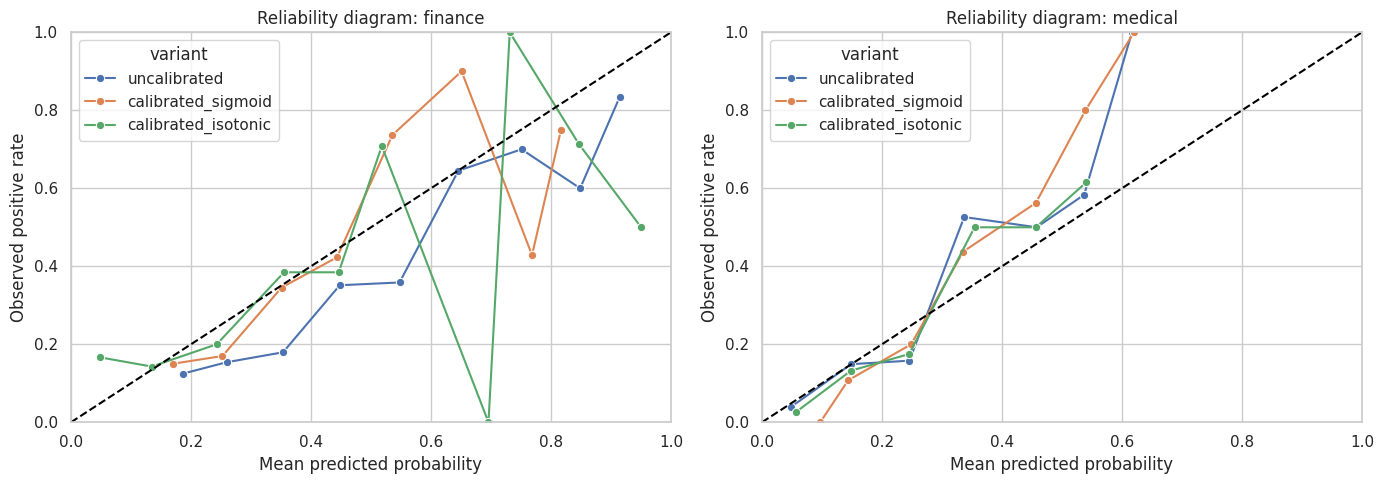

In [6]:
# Что делаем: Строим графики для визуальной проверки гипотез и выводов.
# Зачем: Графики помогают увидеть закономерности, которые неочевидны по одной таблице метрик.
# Как читать результат: Сопоставьте форму графика с числовыми метриками: они должны подтверждать друг друга.
# Типичные ошибки: Частая ошибка — делать вывод только по картинке без проверки числовых значений.

# График 1: диаграмма надежности
datasets_sorted = sorted(reliability_summary['dataset'].unique())
fig, axes = plt.subplots(1, len(datasets_sorted), figsize=(7 * len(datasets_sorted), 5), squeeze=False)

# Итерируемся по объектам и последовательно накапливаем результаты.
for idx, dataset_name in enumerate(datasets_sorted):
    ax = axes[0, idx]
    ds = reliability_summary[reliability_summary['dataset'] == dataset_name]
    # Строим визуализацию и проверяем интерпретируемость результата.
    sns.lineplot(data=ds, x='prob_mean', y='target_rate', hue='variant', marker='o', ax=ax)
    ax.plot([0, 1], [0, 1], '--', color='black', label='ideal')
    ax.set_title(f'Reliability diagram: {dataset_name}')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Observed positive rate')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

# Строим визуализацию и проверяем интерпретируемость результата.
plt.tight_layout()
plt.show()


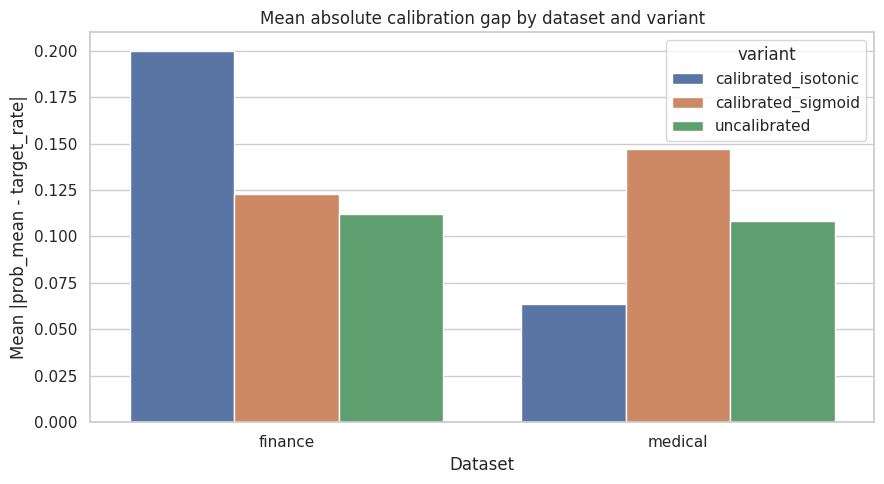

,dataset,variant,mean_abs_gap
0,finance,calibrated_isotonic,0.199856
1,finance,calibrated_sigmoid,0.123067
2,finance,uncalibrated,0.112089
3,medical,calibrated_isotonic,0.063455
4,medical,calibrated_sigmoid,0.147241
5,medical,uncalibrated,0.108372


In [7]:
# Что делаем: Строим графики для визуальной проверки гипотез и выводов.
# Зачем: Графики помогают увидеть закономерности, которые неочевидны по одной таблице метрик.
# Как читать результат: Сопоставьте форму графика с числовыми метриками: они должны подтверждать друг друга.
# Типичные ошибки: Частая ошибка — делать вывод только по картинке без проверки числовых значений.

# График 2: средний разрыв калибровки (calibration gap)
gap_summary = (
    reliability_summary.groupby(['dataset', 'variant'], as_index=False)['abs_gap']
    .mean()
    .rename(columns={'abs_gap': 'mean_abs_gap'})
)

# Строим визуализацию и проверяем интерпретируемость результата.
plt.figure(figsize=(9, 5))
sns.barplot(data=gap_summary, x='dataset', y='mean_abs_gap', hue='variant')
plt.title('Mean absolute calibration gap by dataset and variant')
plt.ylabel('Mean |prob_mean - target_rate|')
plt.xlabel('Dataset')
plt.tight_layout()
plt.show()

gap_summary


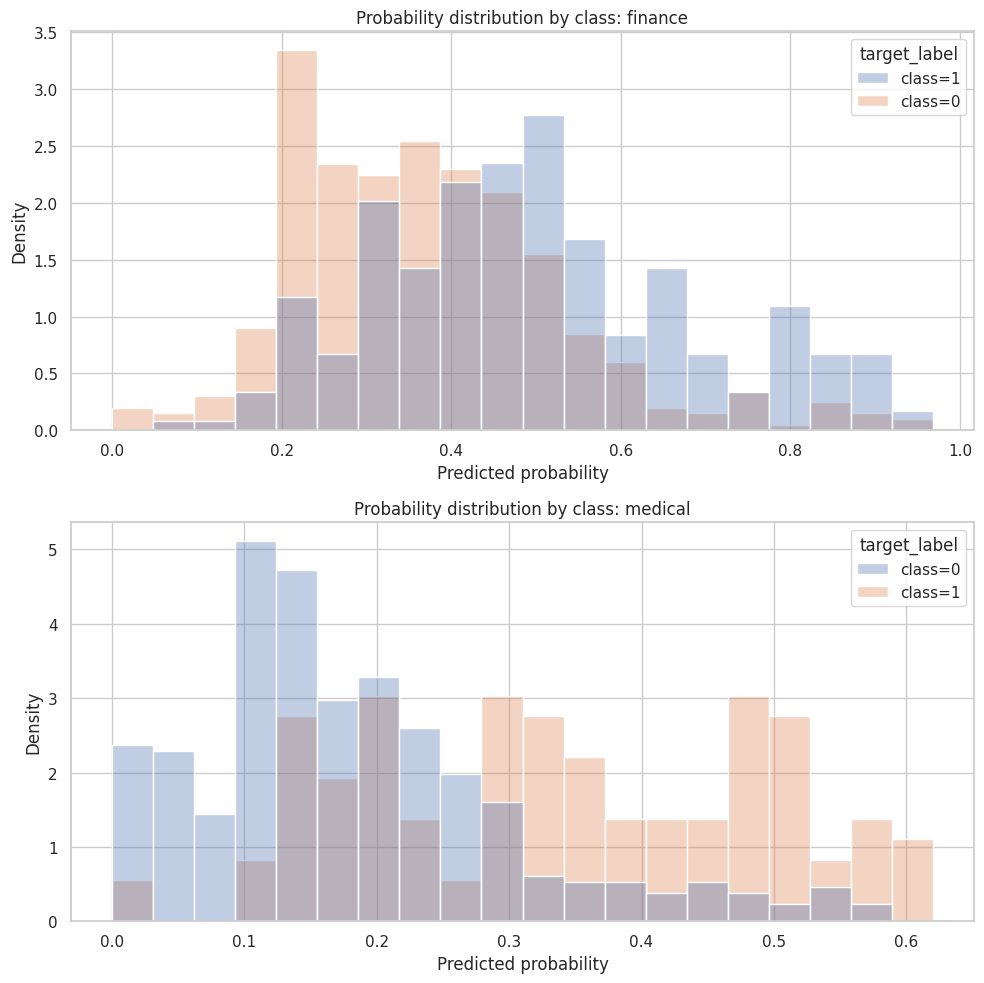

In [8]:
# Что делаем: Строим графики для визуальной проверки гипотез и выводов.
# Зачем: Графики помогают увидеть закономерности, которые неочевидны по одной таблице метрик.
# Как читать результат: Сопоставьте форму графика с числовыми метриками: они должны подтверждать друг друга.
# Типичные ошибки: Частая ошибка — делать вывод только по картинке без проверки числовых значений.

# График 3: распределение вероятностей по классам
fig, axes = plt.subplots(len(datasets_sorted), 1, figsize=(10, 5 * len(datasets_sorted)), squeeze=False)

# Итерируемся по объектам и последовательно накапливаем результаты.
for idx, dataset_name in enumerate(datasets_sorted):
    ax = axes[idx, 0]
    subset = score_distribution[score_distribution['dataset'] == dataset_name].copy()
    subset['target_label'] = subset['target'].map({0: 'class=0', 1: 'class=1'})
    # Строим визуализацию и проверяем интерпретируемость результата.
    sns.histplot(
        data=subset,
        x='score',
        hue='target_label',
        multiple='layer',
        stat='density',
        common_norm=False,
        bins=20,
        alpha=0.35,
        ax=ax,
    )
    ax.set_title(f'Probability distribution by class: {dataset_name}')
    ax.set_xlabel('Predicted probability')

# Строим визуализацию и проверяем интерпретируемость результата.
plt.tight_layout()
plt.show()


### Мини-вывод (пример)
Графики надежности показывают не только итоговый ECE, но и конкретные зоны, где модель переоценивает или недооценивает вероятность события.
Такой разбор делает выбор варианта калибровки прозрачным и объяснимым.

Переход к следующему шагу: объединяем выводы по метрикам и графикам и выбираем `calibrated_best`.


## Шаг 4. Выбор `calibrated_best` по проверочной выборке `validation`

### Что делаем
Выбираем лучший калиброванный вариант для каждого набора данных и сравниваем его с `uncalibrated`.

### Зачем
В ноутбуке 2 мы сравниваем только два кандидата: исходный и лучший калиброванный.

### Вход
`calibration_audit`.

### Выход
`calibrated_best_summary`.

### Проверь себя
- Ровно один `calibrated_best` на каждый набор данных?
- Выбор опирается только на `validation`?

### Мини-вывод
Коротко зафиксируйте правило выбора и его обоснование.

Переход к следующему шагу: сохраняем `calibration_audit.csv` как вход для ноутбука 2.


In [9]:
# Что делаем: Получаем прогнозы и рассчитываем метрики качества.
# Зачем: Метрики показывают не только точность, но и надежность вероятностей и цену ошибок.
# Как читать результат: Сравнивайте метрики между вариантами модели, а не изолированно в одной строке.
# Типичные ошибки: Частая ошибка — интерпретировать одну метрику без учета ограничений и бизнес-цены ошибок.

summary_rows = []
# Итерируемся по объектам и последовательно накапливаем результаты.
for dataset_name in sorted(lab.DATASET_PATHS):
    best_variant = lab.choose_best_calibrated_variant(calibration_audit, dataset_name=dataset_name)
    uncalibrated_row = calibration_audit[
        (calibration_audit['dataset'] == dataset_name)
        & (calibration_audit['variant'] == 'uncalibrated')
    ].iloc[0]
    best_row = calibration_audit[
        (calibration_audit['dataset'] == dataset_name)
        & (calibration_audit['variant'] == best_variant)
    ].iloc[0]

    summary_rows.append(
        {
            'dataset': dataset_name,
            'calibrated_best_source': best_variant,
            'uncalibrated_brier': float(uncalibrated_row['brier']),
            'best_brier': float(best_row['brier']),
            'uncalibrated_ece': float(uncalibrated_row['ece']),
            'best_ece': float(best_row['ece']),
        }
    )

calibrated_best_summary = pd.DataFrame(summary_rows)
calibrated_best_summary


,dataset,calibrated_best_source,uncalibrated_brier,best_brier,uncalibrated_ece,best_ece
0,finance,calibrated_sigmoid,0.217580,0.203700,0.123295,0.068569
1,medical,calibrated_isotonic,0.137501,0.134478,0.050944,0.049939


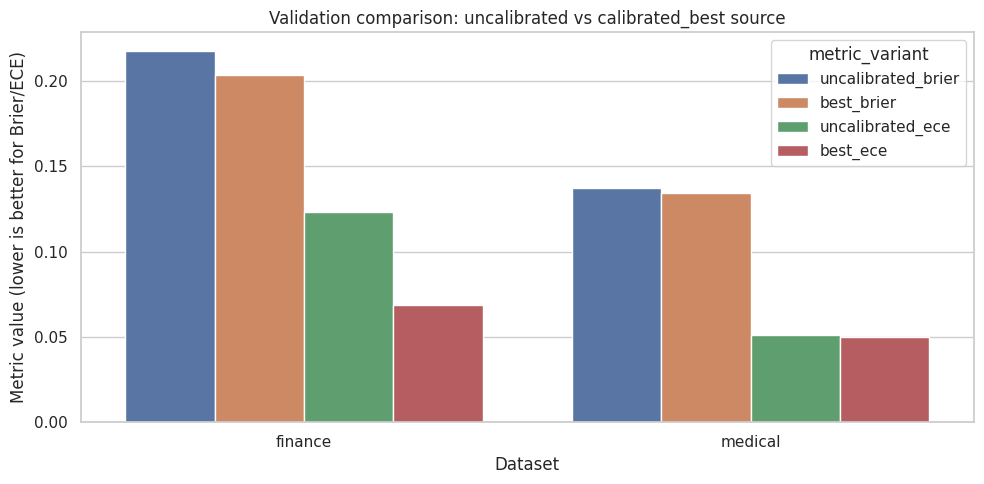

In [10]:
# Что делаем: Получаем прогнозы и рассчитываем метрики качества.
# Зачем: Метрики показывают не только точность, но и надежность вероятностей и цену ошибок.
# Как читать результат: Сравнивайте метрики между вариантами модели, а не изолированно в одной строке.
# Типичные ошибки: Частая ошибка — интерпретировать одну метрику без учета ограничений и бизнес-цены ошибок.

compare_plot = calibrated_best_summary.melt(
    id_vars=['dataset', 'calibrated_best_source'],
    value_vars=['uncalibrated_brier', 'best_brier', 'uncalibrated_ece', 'best_ece'],
    var_name='metric_variant',
    value_name='value',
)

# Строим визуализацию и проверяем интерпретируемость результата.
plt.figure(figsize=(10, 5))
sns.barplot(data=compare_plot, x='dataset', y='value', hue='metric_variant')
plt.title('Validation comparison: uncalibrated vs calibrated_best source')
plt.ylabel('Metric value (lower is better for Brier/ECE)')
plt.xlabel('Dataset')
plt.tight_layout()
plt.show()


### Мини-вывод (пример)
Для каждого набора данных выбран калиброванный вариант с лучшими вероятностными метриками на `validation`.
Этот выбор становится входом для подбора порога в следующем ноутбуке.

Переход к следующему шагу: сохраняем `calibration_audit.csv` как вход для ноутбука 2.


## Шаг 5. Экспорт обязательного артефакта

### Что делаем
Сохраняем `calibration_audit.csv`.

### Зачем
Ноутбук 2 использует этот файл как входной контракт.

### Вход
`calibration_audit`.

### Выход
`outputs/calibration_audit.csv`.

### Проверь себя
- Колонки совпадают с контрактом?
- В `split` только `validation`?

### Мини-вывод
Подтвердите, что артефакт экспортирован и готов к использованию в ноутбуке 2.

Переход к следующему шагу: ноутбук завершен, файл готов для выбора порога в следующем ноутбуке.


In [11]:
# Что делаем: Загружаем входные данные и артефакты предыдущих шагов.
# Зачем: Этот шаг задает исходный контекст: без него метрики и графики будут считаться по неверным данным.
# Как читать результат: Проверьте размеры таблиц и названия ключевых колонок: это главный индикатор корректной загрузки.
# Типичные ошибки: Частая ошибка — использовать не тот файл или устаревший артефакт из другой лабораторной работы.

output_path = OUTPUT_DIR / 'calibration_audit.csv'
# Сохраняем таблицу артефакта в CSV.
calibration_audit.to_csv(output_path, index=False)

print(f'Saved: {output_path.resolve()} | rows={len(calibration_audit)}')
print('Split values:', sorted(calibration_audit['split'].unique().tolist()))


Saved: /home/sorcerer/Projects/edu-big-data-machine-models/04-calibration-threshold-and-decision-policy/outputs/calibration_audit.csv | rows=6
Split values: ['validation']
